# 01 — Data Preprocessing
**Indoor WiFi Fingerprinting Localization**

Raw data → per-scan RSSI fingerprint vectors, ready for feature extraction.

### What each raw CSV looks like
Each row = one AP detected during one scan at one location.
Multiple rows share the same timestamp (one per visible AP).

### Goal
Pivot each scan timestamp into a single row where:
- columns = BSSID (unique AP identifiers)
- values  = RSSI (signal strength in dBm)
- missing = `RSSI_MISSING` sentinel (-100 dBm, below noise floor)

In [3]:
!pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl (12.3 MB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.wh

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

In [8]:
ROOT       = Path('../../')
DATA_RAW   = ROOT / 'Data' / '01_Wifi_Daytime'
DATA_PROC  = ROOT / 'Data' / '02_Processed_Wifi_Daytime'
DATA_PROC.mkdir(parents=True, exist_ok=True)


RSSI_MISSING = -100   # sentinel for APs not detected in a scan
COL_NAMES = ['Timestamp', 'SSID', 'BSSID', 'RSSI', 'Frequency',
             'Activity_Label', 'Location_Label']

print(f'Raw data dir : {DATA_RAW.resolve()}')
print(f'Processed dir: {DATA_PROC.resolve()}')

Raw data dir : D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\01_Wifi_Daytime
Processed dir: D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\02_Processed_Wifi_Daytime


## 1. Load all raw CSV files

In [9]:
csv_files = sorted(DATA_RAW.glob('*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {f.name}')

Found 19 CSV files:
  01_Opposite DLT8_2, near stairs.csv
  02_Between DLT8 Stairs and Faculty Chamber Entrance.csv
  03_Faculty Chamber Entrance opposite DLT8.csv
  04_Garden between faculty Chamber and computational Lab.csv
  05_Near the stairs to the 1st floor.csv
  06_Between DLT7 and Stairs.csv
  07_opposite DLT7_2 Stairs.csv
  08_Garden Between DLT7 and DLT8 Stairs.csv
  09_D-151_1 Computation Lab, next to the stairs.csv
  10_D-152.csv
  11_D-151_2_D-153_1.csv
  12_D-154.csv
  13_D-153_2 SMART Space.csv
  14_2nd faculty Chamber Entrance on the ground floor.csv
  15_Opposite CSIS Meeting Room.csv
  16_D-157,158,159,160.csv
  17_D-161,162,163,164.csv
  18_D-165,166,167,168.csv
  19_D-169, CAIR.csv


In [10]:
frames = []
for f in csv_files:
    df = pd.read_csv(f, header=0, names=COL_NAMES)
    # strip whitespace from string columns
    for c in ['SSID', 'BSSID', 'Activity_Label', 'Location_Label']:
        df[c] = df[c].astype(str).str.strip()
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)
print(f'Total rows: {len(raw):,}')
print(f'Columns   : {raw.columns.tolist()}')
raw.head()

Total rows: 17,210
Columns   : ['Timestamp', 'SSID', 'BSSID', 'RSSI', 'Frequency', 'Activity_Label', 'Location_Label']


,Timestamp,SSID,BSSID,RSSI,Frequency,Activity_Label,Location_Label
0,2026-03-16T14:15:50.985830,BPGC-NAB,4c:77:6d:10:31:ee,-88,5500,STATIONARY,Stairs_Opp_DLT8_2
1,2026-03-16T14:15:50.985830,NaN,4c:77:6d:10:31:ef,-86,5500,STATIONARY,Stairs_Opp_DLT8_2
2,2026-03-16T14:15:50.985830,NaN,08:4f:a9:30:00:0f,-87,5805,STATIONARY,Stairs_Opp_DLT8_2
3,2026-03-16T14:15:50.985830,BPGC-NAB,08:4f:a9:30:00:0e,-87,5805,STATIONARY,Stairs_Opp_DLT8_2
4,2026-03-16T14:15:50.985830,JioFi3_423A06,f8:da:0c:42:3a:06,-85,2432,STATIONARY,Stairs_Opp_DLT8_2


## 2. Exploratory Data Analysis

In [12]:
print('=== Data Types ===')
print(raw.dtypes)
print('\n=== Null Counts ===')
print(raw.isnull().sum())


=== Data Types ===
Timestamp           str
SSID                str
BSSID               str
RSSI              int64
Frequency         int64
Activity_Label      str
Location_Label      str
dtype: object

=== Null Counts ===
Timestamp            0
SSID              5796
BSSID                0
RSSI                 0
Frequency            0
Activity_Label       0
Location_Label       0
dtype: int64


In [13]:
print('=== Location labels (19 expected) ===')
loc_counts = raw['Location_Label'].value_counts()
print(loc_counts)
print(f'\nUnique locations: {loc_counts.shape[0]}')

=== Location labels (19 expected) ===
Location_Label
Stairs_Opp_DLT8_2                          1183
Btw_DLT_8_and_F_Chamber_Entrance           1136
F_Chamber_Entrance_Opp_DLT8                1065
Garden_Btw_DLT7_DLT8_Stairs                1025
Opposite_DLT7_2                            1002
Garden_Btw_F_Cham_and_Computational_Lab     945
D-151/1 Computation Lab                     935
Btw_Stairs_and_DLT7                         930
F_Chamber_Entrance_2                        929
D-169, CAIR                                 910
D-151/2_D-153/1                             831
D-152                                       828
D-154                                       823
D-165,166,167,168                           811
Near_Stairs_To_1st_Floor                    801
D-157,158,159,160                           775
D-161,162,163,164                           767
D-153/2 SMART Space                         763
Opp_CSIS_Meeting_Room                       751
Name: count, dtype: int64

Unique l

=== RSSI stats ===
count    17210.000000
mean       -73.446136
std         13.401358
min        -93.000000
25%        -84.000000
50%        -77.000000
75%        -65.000000
max        -23.000000
Name: RSSI, dtype: float64


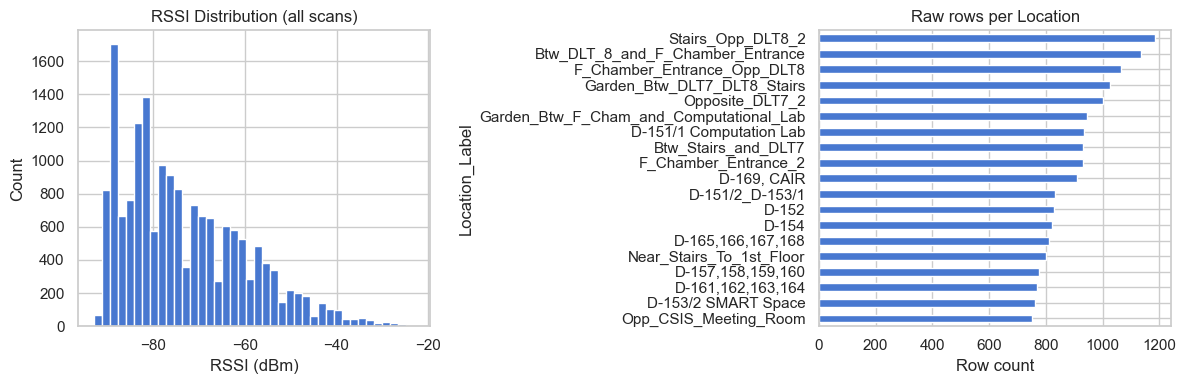

In [14]:
# RSSI sanity check
print('=== RSSI stats ===')
print(raw['RSSI'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RSSI distribution
axes[0].hist(raw['RSSI'], bins=40, edgecolor='white')
axes[0].set_title('RSSI Distribution (all scans)')
axes[0].set_xlabel('RSSI (dBm)')
axes[0].set_ylabel('Count')

# Rows per location
loc_counts.plot(kind='barh', ax=axes[1])
axes[1].set_title('Raw rows per Location')
axes[1].set_xlabel('Row count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(DATA_PROC / 'eda_raw.png', dpi=100)
plt.show()

In [18]:
# Unique BSSIDs
print(f'Unique BSSIDs : {raw["BSSID"].nunique()}')
print(f'Unique SSIDs  : {raw["SSID"].nunique()}')
print(f'Frequency bands: {raw["Frequency"].nunique()}')
print(f'Frequency bands: {sorted(raw["Frequency"].unique())}')

Unique BSSIDs : 182
Unique SSIDs  : 20
Frequency bands: 22
Frequency bands: [np.int64(2412), np.int64(2422), np.int64(2432), np.int64(2437), np.int64(2442), np.int64(2452), np.int64(2457), np.int64(2462), np.int64(5180), np.int64(5220), np.int64(5240), np.int64(5260), np.int64(5320), np.int64(5500), np.int64(5560), np.int64(5580), np.int64(5620), np.int64(5660), np.int64(5700), np.int64(5720), np.int64(5745), np.int64(5805)]


## 3. Parse timestamps & count scans per location

In [19]:
raw['Timestamp'] = pd.to_datetime(raw['Timestamp'])

# Each unique (Timestamp, Location_Label) pair = one scan
scan_key = ['Timestamp', 'Location_Label']
scans_per_loc = (raw.groupby('Location_Label')['Timestamp']
                    .nunique()
                    .sort_values(ascending=False))

print('Scans per location:')
print(scans_per_loc)
print(f'\nTotal unique scans: {scans_per_loc.sum()}')

Scans per location:
Location_Label
Btw_DLT_8_and_F_Chamber_Entrance           24
Btw_Stairs_and_DLT7                        24
D-151/1 Computation Lab                    24
D-151/2_D-153/1                            24
D-152                                      24
D-153/2 SMART Space                        24
D-157,158,159,160                          24
D-165,166,167,168                          24
D-161,162,163,164                          24
D-169, CAIR                                24
F_Chamber_Entrance_2                       24
Near_Stairs_To_1st_Floor                   24
F_Chamber_Entrance_Opp_DLT8                24
Garden_Btw_DLT7_DLT8_Stairs                24
Garden_Btw_F_Cham_and_Computational_Lab    24
Opposite_DLT7_2                            24
Opp_CSIS_Meeting_Room                      24
Stairs_Opp_DLT8_2                          24
D-154                                      23
Name: Timestamp, dtype: int64

Total unique scans: 455


## 4. Handle duplicate BSSID within same scan
If the same AP appears twice in one scan, keep the stronger (max) RSSI reading.

In [20]:
dupes = raw.duplicated(subset=['Timestamp', 'Location_Label', 'BSSID'], keep=False)
print(f'Duplicate (Timestamp, Location, BSSID) rows: {dupes.sum()}')

# Aggregate: keep max RSSI if duplicated
raw_clean = (raw.groupby(['Timestamp', 'Location_Label', 'BSSID'], as_index=False)
               .agg({'RSSI': 'max', 'SSID': 'first', 'Frequency': 'first',
                     'Activity_Label': 'first'}))

print(f'Rows after dedup: {len(raw_clean):,}')

Duplicate (Timestamp, Location, BSSID) rows: 0
Rows after dedup: 17,210


## 5. Pivot → per-scan fingerprint matrix
Shape after pivot: `(n_scans, n_unique_bssids + metadata columns)`

In [21]:
# Pivot: rows=scans, columns=BSSID, values=RSSI
fingerprints = raw_clean.pivot_table(
    index=['Timestamp', 'Location_Label', 'Activity_Label'],
    columns='BSSID',
    values='RSSI',
    aggfunc='max'
).reset_index()

fingerprints.columns.name = None  # remove 'BSSID' label on axis

n_scans = len(fingerprints)
bssid_cols = [c for c in fingerprints.columns
              if c not in ('Timestamp', 'Location_Label', 'Activity_Label')]
n_aps = len(bssid_cols)

print(f'Scans    : {n_scans}')
print(f'APs (cols): {n_aps}')
fingerprints.head(3)

Scans    : 455
APs (cols): 182


,Timestamp,Location_Label,Activity_Label,00:27:e3:29:d2:a0,00:27:e3:29:d2:af,00:27:e3:29:d2:e0,00:27:e3:29:db:e0,00:27:e3:29:dc:00,00:27:e3:29:e8:80,00:27:e3:29:e8:8f,...,cc:db:93:65:2d:20,cc:db:93:65:30:0f,cc:db:93:65:52:0f,da:b3:2f:cd:22:39,e2:bb:9e:59:1c:fd,ee:91:61:62:68:1c,ee:91:61:62:97:64,f8:da:0c:42:3a:06,fc:01:7c:92:66:80,fe:bf:77:35:66:79
0,2026-03-16 14:15:50.985830,Stairs_Opp_DLT8_2,STATIONARY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-85.0,NaN,NaN
1,2026-03-16 14:15:53.300330,Stairs_Opp_DLT8_2,STATIONARY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-16 14:15:57.319555,Stairs_Opp_DLT8_2,STATIONARY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Fill missing AP observations with RSSI_MISSING
fingerprints[bssid_cols] = fingerprints[bssid_cols].fillna(RSSI_MISSING)

missing_pct = (fingerprints[bssid_cols] == RSSI_MISSING).mean().mean() * 100
print(f'Sparsity: {missing_pct:.1f}% of (scan × AP) entries are missing → filled with {RSSI_MISSING}')

Sparsity: 79.2% of (scan × AP) entries are missing → filled with -100


## 6. Quality checks

Scans per location:
Location_Label
Btw_DLT_8_and_F_Chamber_Entrance           24
Btw_Stairs_and_DLT7                        24
D-151/1 Computation Lab                    24
D-151/2_D-153/1                            24
D-152                                      24
D-153/2 SMART Space                        24
D-154                                      23
D-157,158,159,160                          24
D-161,162,163,164                          24
D-165,166,167,168                          24
D-169, CAIR                                24
F_Chamber_Entrance_2                       24
F_Chamber_Entrance_Opp_DLT8                24
Garden_Btw_DLT7_DLT8_Stairs                24
Garden_Btw_F_Cham_and_Computational_Lab    24
Near_Stairs_To_1st_Floor                   24
Opp_CSIS_Meeting_Room                      24
Opposite_DLT7_2                            24
Stairs_Opp_DLT8_2                          24
Name: count, dtype: int64


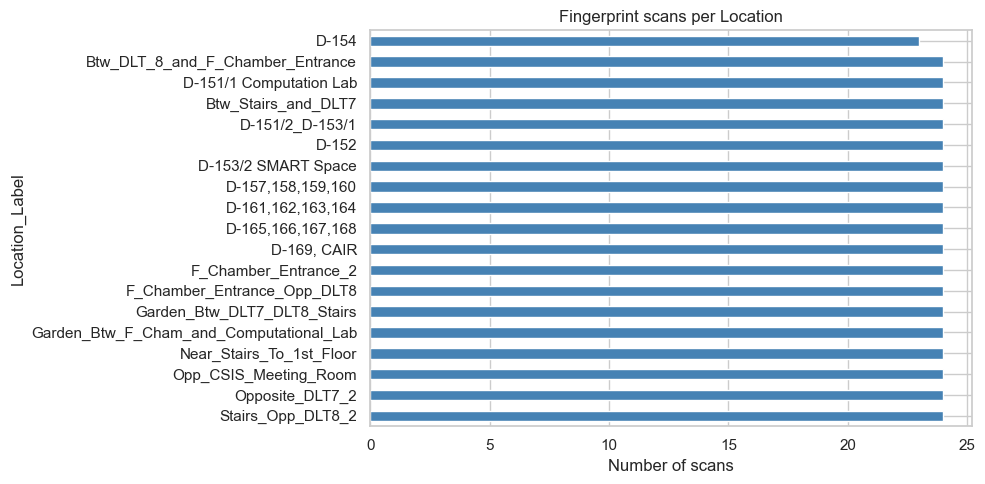

In [23]:
# Scans per location (should be balanced)
scan_balance = fingerprints['Location_Label'].value_counts().sort_index()
print('Scans per location:')
print(scan_balance)

fig, ax = plt.subplots(figsize=(10, 5))
scan_balance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Fingerprint scans per Location')
ax.set_xlabel('Number of scans')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROC / 'scans_per_location.png', dpi=100)
plt.show()

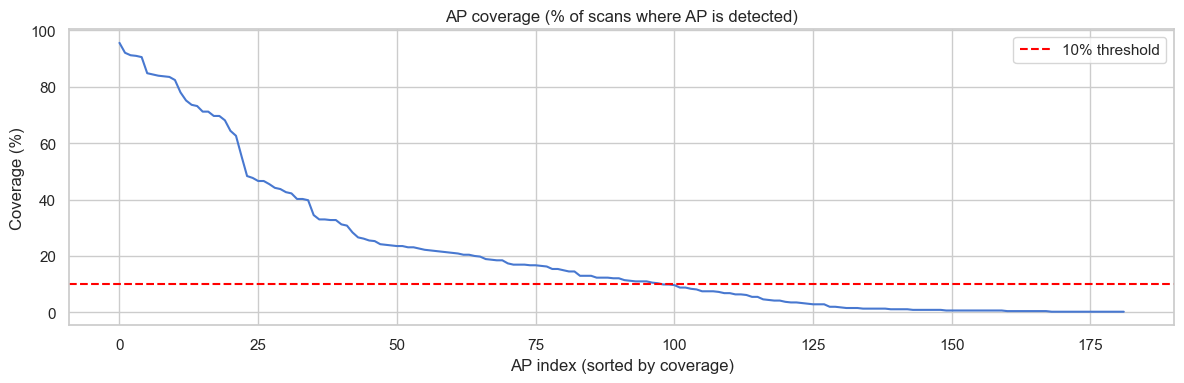

APs with >50% coverage : 23
APs with >10% coverage : 98
APs with <= 1% coverage: 39


In [24]:
# AP coverage: how many scans (%) detect each AP
ap_coverage = ((fingerprints[bssid_cols] > RSSI_MISSING).mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(ap_coverage)), ap_coverage.values)
ax.axhline(10, color='red', linestyle='--', label='10% threshold')
ax.set_title('AP coverage (% of scans where AP is detected)')
ax.set_xlabel('AP index (sorted by coverage)')
ax.set_ylabel('Coverage (%)')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / 'ap_coverage.png', dpi=100)
plt.show()

print(f'APs with >50% coverage : {(ap_coverage > 50).sum()}')
print(f'APs with >10% coverage : {(ap_coverage > 10).sum()}')
print(f'APs with <= 1% coverage: {(ap_coverage <= 1).sum()}')

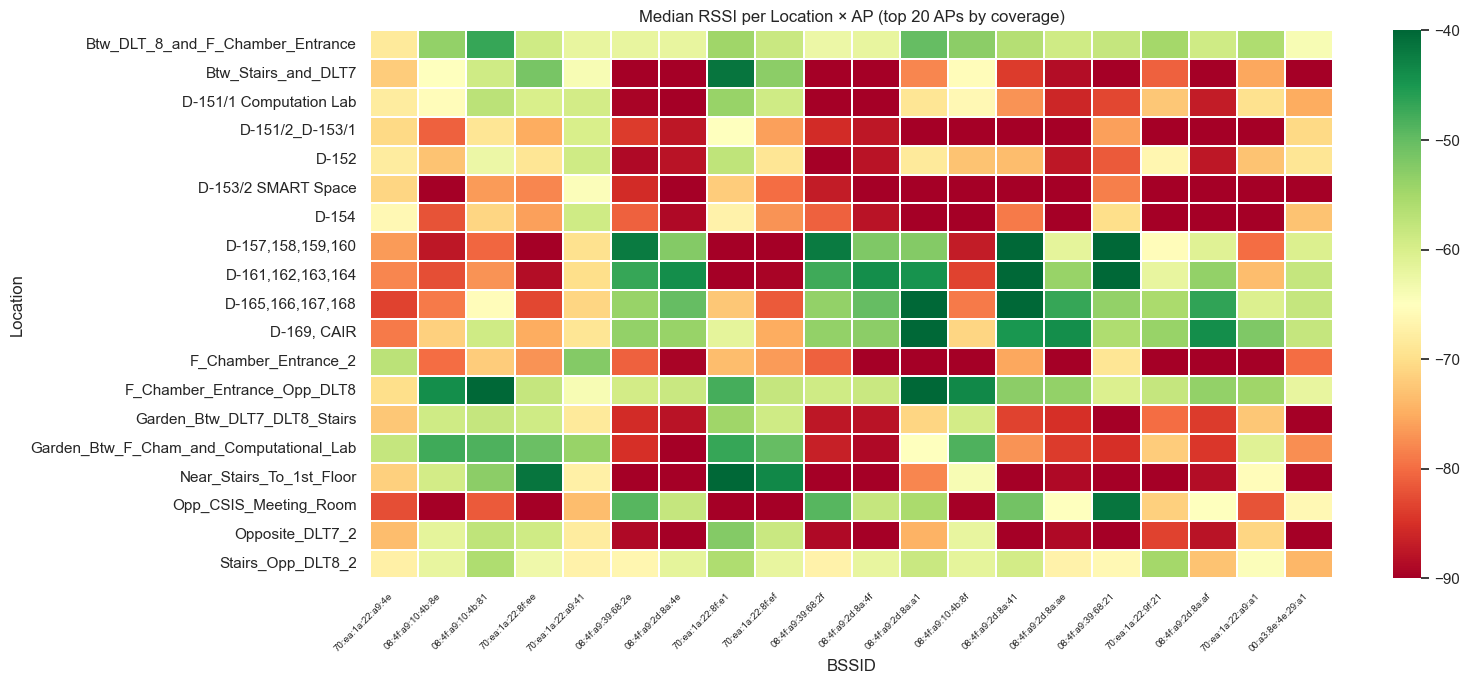

In [25]:
# RSSI heatmap: median RSSI per (location, top-20 APs)
top_aps = ap_coverage.head(20).index.tolist()
heatmap_data = fingerprints.groupby('Location_Label')[top_aps].median()

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, annot=False, fmt='.0f', cmap='RdYlGn',
            vmin=-90, vmax=-40, ax=ax, linewidths=0.3)
ax.set_title('Median RSSI per Location × AP (top 20 APs by coverage)')
ax.set_xlabel('BSSID')
ax.set_ylabel('Location')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.savefig(DATA_PROC / 'rssi_heatmap.png', dpi=100)
plt.show()

## 7. Save preprocessed data

In [32]:
out_path = DATA_PROC / 'fingerprints.csv'
fingerprints.to_csv(out_path, index=False)
print(f'Saved: {out_path.resolve()}')
print(f'Shape: {fingerprints.shape}')

# Also save AP coverage for use in feature extraction
ap_coverage.to_csv(DATA_PROC / 'ap_coverage.csv', header=['coverage_pct'])
print(f'AP coverage saved.')

# Summary
print('\n=== PREPROCESSING SUMMARY ===')
print(f'  Total scans        : {n_scans}')
print(f'  Total locations    : {fingerprints["Location_Label"].nunique()}')
print(f'  Total APs (raw)    : {n_aps}')
print(f'  RSSI range (obs.)  : {raw_clean["RSSI"].min()} to {raw_clean["RSSI"].max()} dBm')
print(f'  Missing sentinel   : {RSSI_MISSING} dBm')
print(f'  Sparsity           : {missing_pct:.1f}%')

Saved: D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\02_Processed_Wifi_Daytime\fingerprints.csv
Shape: (455, 185)
AP coverage saved.

=== PREPROCESSING SUMMARY ===
  Total scans        : 455
  Total locations    : 19
  Total APs (raw)    : 182
  RSSI range (obs.)  : -93 to -23 dBm
  Missing sentinel   : -100 dBm
  Sparsity           : 79.2%
